# Stroke Prediction Dataset Analysis

This analysis will use the Healthcare Stroke Prediction Dataset found here: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset, which contains patient-level medical and information which will be used to predict the age of the patient based on their information in this dataset. It includes variables such as:

Age - patient's age

Gender - patient's gender

Hypertension - whether the patient has high blood pressure or not

Heart disease - whether the patient has heart disease or not

Ever_married - whether the patient is married or not

Smoking status - whether the patient has, is, or has not smoked

BMI - the body mass index of the patient

Glucose levels - the average amount of glucose in the patient's blood

Work type - what the patient does for work

Residence type - whether the patient lives in a rural or urban environment


This analysis will start with a initial overview of the data before going into data cleaning, Exploratory Data Analysis (EDA), and model analysis using linear, polynomial, and ridge regressions.

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

from imblearn.over_sampling import SMOTE

df = pd.read_csv("data.csv")

df.head(10)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


## Overview of Data

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [54]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [55]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


## Data Cleaning

In [56]:
# filling missing BMI data with median
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

In [57]:
df['smoking_status'].value_counts().get('Unknown', 0)

np.int64(1544)

In [58]:
df = df[df['smoking_status'] != 'Unknown']

In [59]:
df = df.drop_duplicates()

In [60]:
df['age'] = df['age'].astype(int)
df['stroke'] = df['stroke'].astype(int)

## EDA

For EDA, I used open AI in order to create the code used below in order to get some practice in giving generative AI useful prompts https://chatgpt.com/share/6a444391-97ac-83ea-b55f-c1ef8d93684b.

Descriptive Statistics

Age
count    3566.000000
mean       48.853898
std        18.874375
min        10.000000
25%        34.000000
50%        50.000000
75%        63.000000
max        82.000000
Name: age, dtype: float64

BMI
count    3566.000000
mean       30.204066
std         7.163906
min        11.500000
25%        25.400000
50%        28.750000
75%        33.800000
max        92.000000
Name: bmi, dtype: float64

Average Glucose Level
count    3566.000000
mean      108.982011
std        48.292204
min        55.120000
25%        77.460000
50%        92.650000
75%       116.677500
max       271.740000
Name: avg_glucose_level, dtype: float64


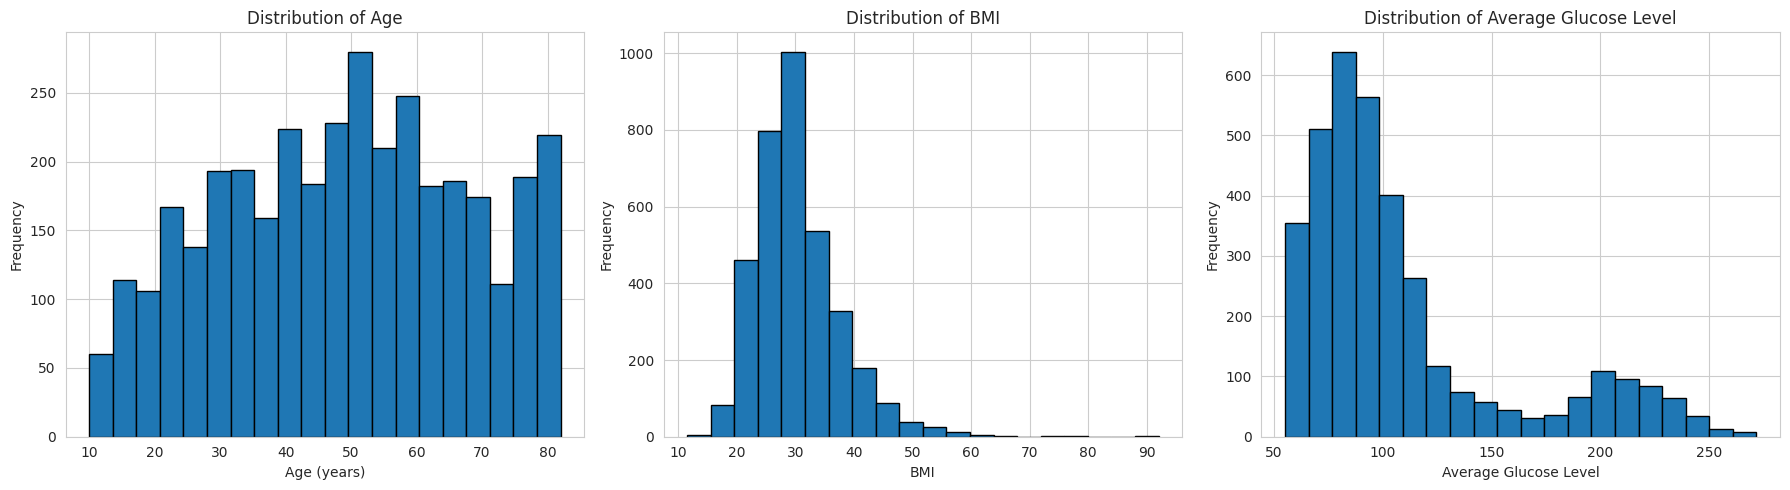

In [61]:
# Display descriptive statistics
print("Descriptive Statistics")
print("=" * 50)
print("\nAge")
print(df["age"].describe())

print("\nBMI")
print(df["bmi"].describe())

print("\nAverage Glucose Level")
print(df["avg_glucose_level"].describe())

# Create histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age histogram
axes[0].hist(df["age"], bins=20, edgecolor="black")
axes[0].set_title("Distribution of Age")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Frequency")

# BMI histogram (exclude missing values)
axes[1].hist(df["bmi"].dropna(), bins=20, edgecolor="black")
axes[1].set_title("Distribution of BMI")
axes[1].set_xlabel("BMI")
axes[1].set_ylabel("Frequency")

# Average glucose level histogram
axes[2].hist(df["avg_glucose_level"], bins=20, edgecolor="black")
axes[2].set_title("Distribution of Average Glucose Level")
axes[2].set_xlabel("Average Glucose Level")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

The descriptive statistics give a quick overview of the dataset. The average age is around 49 years, with ages ranging from 10 to 82, showing that the dataset includes people from many age groups. The average BMI is about 30, which falls into the overweight range, while average glucose levels vary much more across patients. These statistics help identify the general distribution of the data before moving into more detailed analysis.

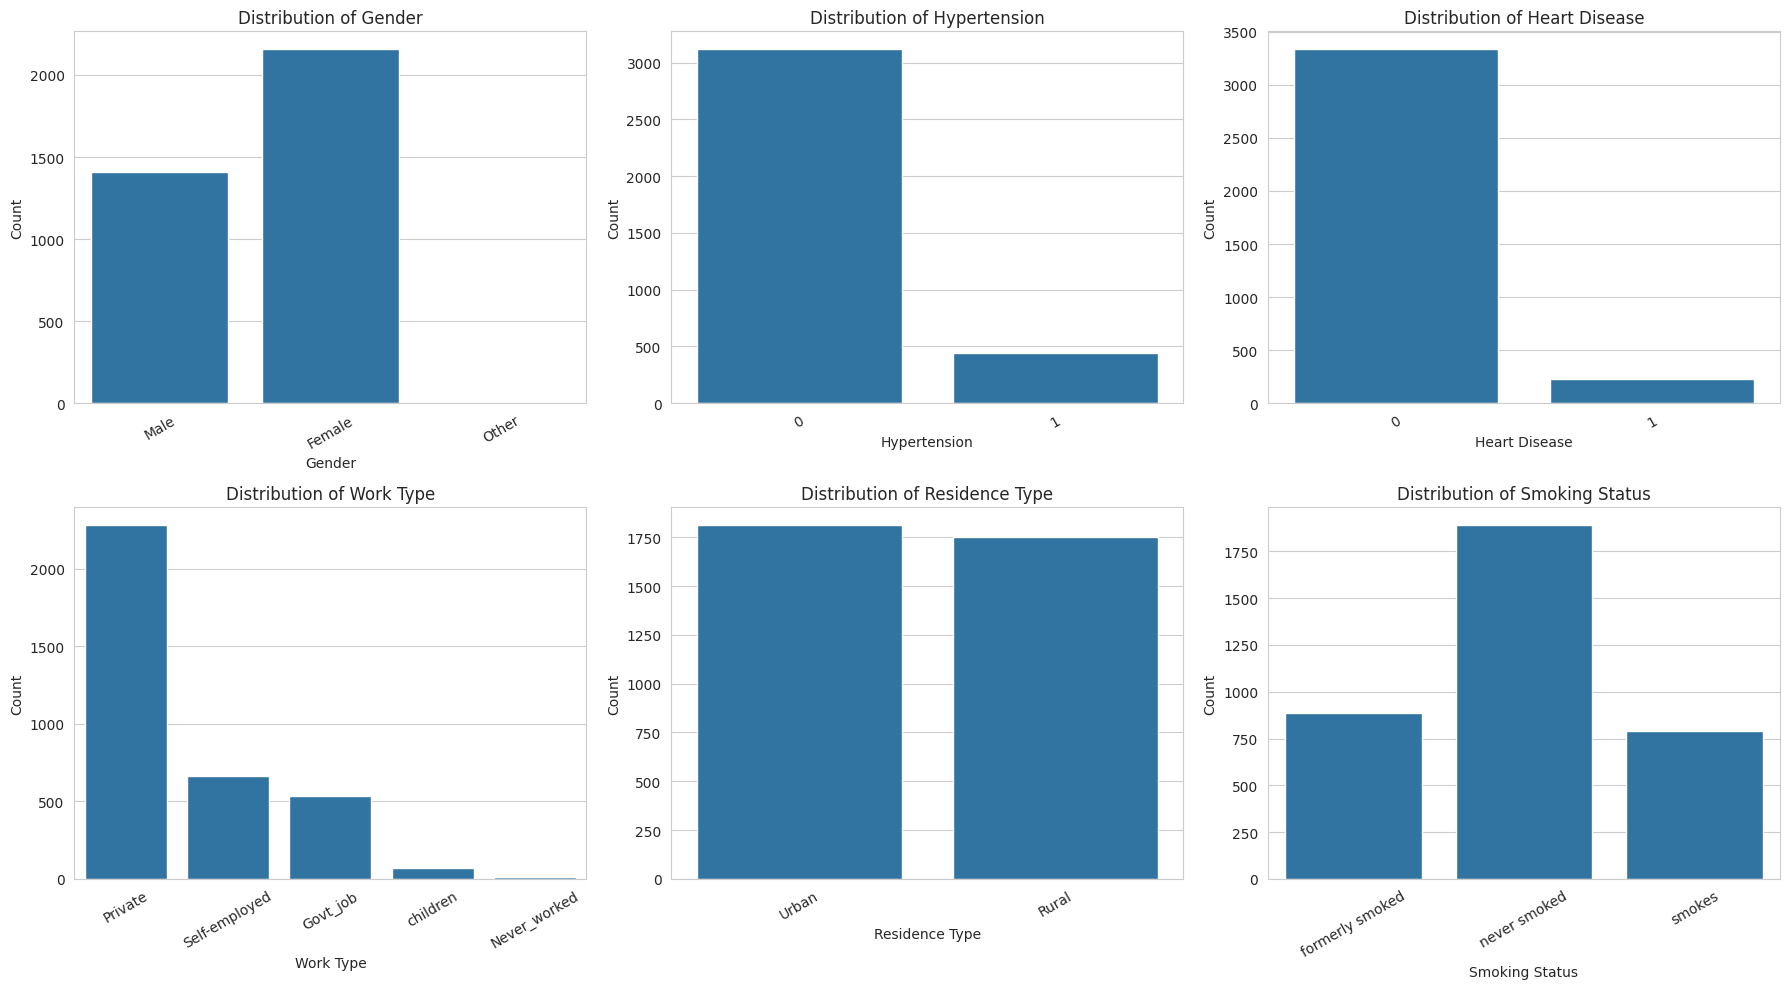


GENDER
gender
Female    2158
Male      1407
Other        1
Name: count, dtype: int64

HYPERTENSION
hypertension
0    3120
1     446
Name: count, dtype: int64

HEART_DISEASE
heart_disease
0    3338
1     228
Name: count, dtype: int64

WORK_TYPE
work_type
Private          2285
Self-employed     663
Govt_job          535
children           69
Never_worked       14
Name: count, dtype: int64

RESIDENCE_TYPE
Residence_type
Urban    1814
Rural    1752
Name: count, dtype: int64

SMOKING_STATUS
smoking_status
never smoked       1892
formerly smoked     885
smokes              789
Name: count, dtype: int64


In [62]:
# Set plotting style
sns.set_style("whitegrid")

# List of categorical variables
categorical_vars = [
    "gender",
    "hypertension",
    "heart_disease",
    "work_type",
    "Residence_type",
    "smoking_status"
]

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Create countplots
for ax, var in zip(axes, categorical_vars):
    sns.countplot(data=df, x=var, ax=ax)
    ax.set_title(f"Distribution of {var.replace('_', ' ').title()}")
    ax.set_xlabel(var.replace('_', ' ').title())
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Display counts for each variable
for var in categorical_vars:
    print(f"\n{var.upper()}")
    print(df[var].value_counts())

The countplots show that several of the categorical variables are imbalanced. There are more females than males. Most patients do not have hypertension or heart disease, while the majority work in the private sector. Urban and rural residents are split fairly evenly, and the smoking status categories are reasonably balanced. These differences are important because class imbalances can affect how well a model learns from the data.

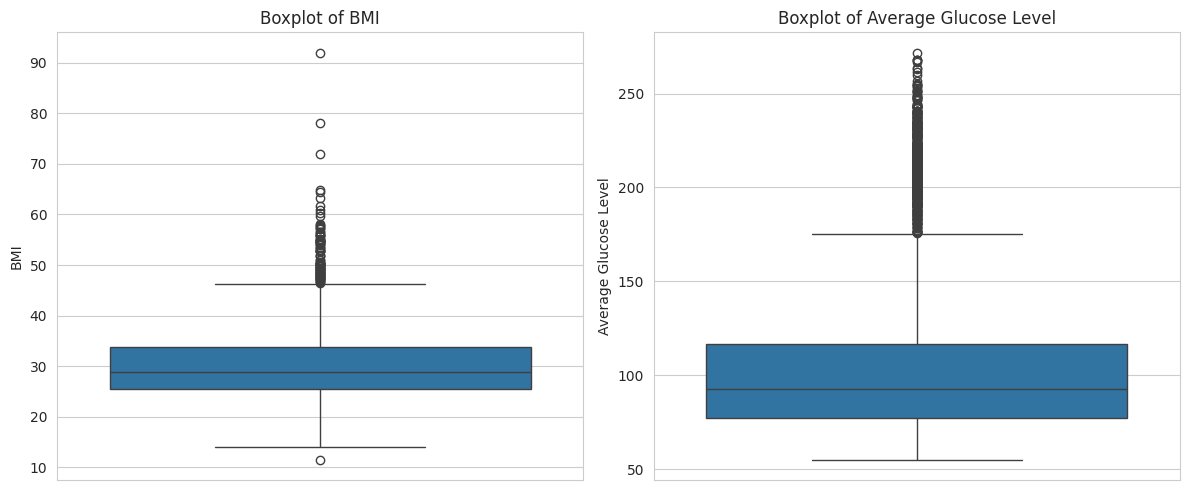


BMI
Q1: 25.40
Q3: 33.80
IQR: 8.40
Lower Bound: 12.80
Upper Bound: 46.40
Number of Outliers: 97

AVG_GLUCOSE_LEVEL
Q1: 77.46
Q3: 116.68
IQR: 39.22
Lower Bound: 18.63
Upper Bound: 175.50
Number of Outliers: 505


In [63]:
# -----------------------------
# Create Boxplots
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# BMI Boxplot
sns.boxplot(y=df["bmi"], ax=axes[0])
axes[0].set_title("Boxplot of BMI")
axes[0].set_ylabel("BMI")

# Average Glucose Level Boxplot
sns.boxplot(y=df["avg_glucose_level"], ax=axes[1])
axes[1].set_title("Boxplot of Average Glucose Level")
axes[1].set_ylabel("Average Glucose Level")

plt.tight_layout()
plt.show()

# -----------------------------
# Function to detect outliers using IQR
# -----------------------------
def detect_outliers(data, column):
    # Remove missing values
    values = data[column].dropna()

    Q1 = values.quantile(0.25)
    Q3 = values.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = values[(values < lower_bound) | (values > upper_bound)]

    print(f"\n{column.upper()}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Number of Outliers: {len(outliers)}")

    return outliers

# Detect outliers
bmi_outliers = detect_outliers(df, "bmi")
glucose_outliers = detect_outliers(df, "avg_glucose_level")

The boxplots were used to identify potential outliers in BMI and average glucose level using the IQR method. BMI had 97 outliers, while average glucose level had 505 outliers. Although these values fall outside the typical range, they are likely to represent real medical conditions rather than errors in the data. Because of this, the outliers were kept in the dataset so the models could learn from the full range of patient information.

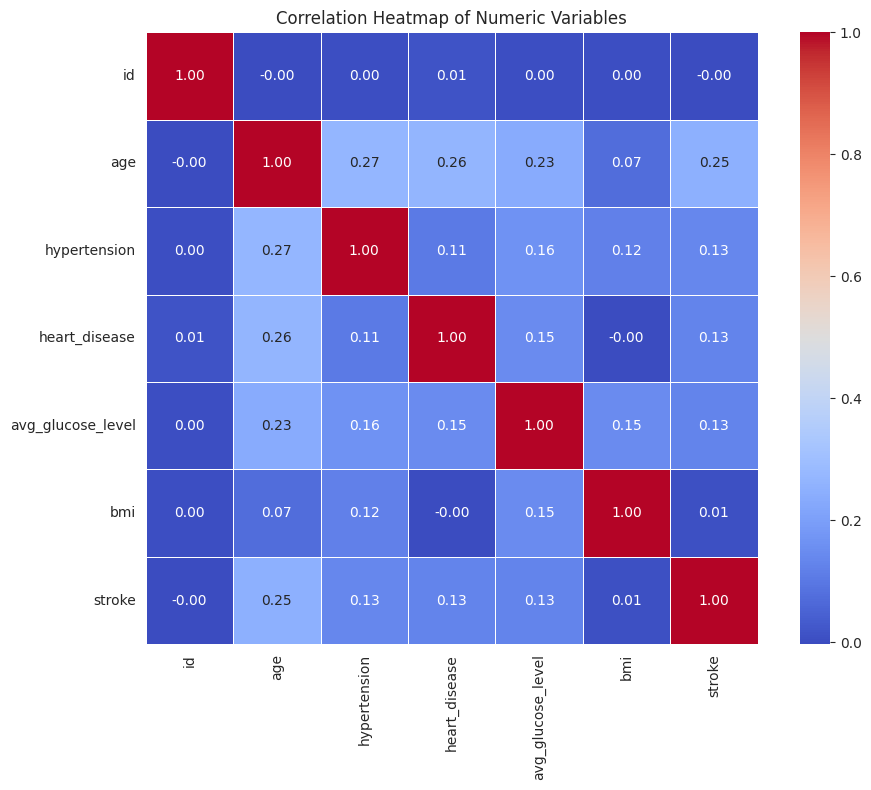

Correlation Matrix
                         id       age  hypertension  heart_disease  \
id                 1.000000 -0.000581      0.000898       0.013567   
age               -0.000581  1.000000      0.269664       0.264300   
hypertension       0.000898  0.269664      1.000000       0.105633   
heart_disease      0.013567  0.264300      0.105633       1.000000   
avg_glucose_level  0.000915  0.232698      0.164568       0.148222   
bmi                0.003908  0.074616      0.121756      -0.003349   
stroke            -0.002587  0.250794      0.134717       0.129346   

                   avg_glucose_level       bmi    stroke  
id                          0.000915  0.003908 -0.002587  
age                         0.232698  0.074616  0.250794  
hypertension                0.164568  0.121756  0.134717  
heart_disease               0.148222 -0.003349  0.129346  
avg_glucose_level           1.000000  0.147150  0.128714  
bmi                         0.147150  1.000000  0.005805  
stroke 

In [64]:
# Select numeric variables
numeric_df = df.select_dtypes(include=["number"])

# Compute correlation matrix
correlation_matrix = numeric_df.corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()

# Display the correlation matrix
print("Correlation Matrix")
print(correlation_matrix)

The correlation heatmap shows how strongly the numeric variables are related to each other. Age has the strongest positive relationship with both hypertension and heart disease, suggesting that these conditions become more common as people get older. Most of the other correlations are fairly weak, which means the variables provide different information and there is little concern about strong multicollinearity.

## Modeling Analysis

Seeing as we are using regression models and the stroke column is categorical and not continuous, I have chosen to use age as the target variable in this analysis. The goal of this is to examine the relationship between age and stroke risk factors.".

In [65]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_never smoked,smoking_status_smokes
0,9046,67,0,1,228.69,36.6,1,True,False,True,False,True,False,False,True,False,False
1,51676,61,0,0,202.21,28.1,1,False,False,True,False,False,True,False,False,True,False
2,31112,80,0,1,105.92,32.5,1,True,False,True,False,True,False,False,False,True,False
3,60182,49,0,0,171.23,34.4,1,False,False,True,False,True,False,False,True,False,True
4,1665,79,1,0,174.12,24.0,1,False,False,True,False,False,True,False,False,True,False


In [66]:
y = df_encoded['age']
X = df_encoded.drop(['age'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [67]:
# Extract single predictor BEFORE scaling
X_single_train = X_train[['avg_glucose_level']].values
X_single_test = X_test[['avg_glucose_level']].values

# Scale the single predictor
scaler_single = StandardScaler()
X_single_train_scaled = scaler_single.fit_transform(X_single_train)
X_single_test_scaled = scaler_single.transform(X_single_test)

Model Performance Metrics

R² (Coefficient of Determination): Measures how much of the variation in the target variable is explained by the model. Values closer to 1 indicate a better fit.

RMSE (Root Mean Squared Error): Measures the average prediction error, giving greater weight to larger errors. Lower values indicate better predictive accuracy.

MAE (Mean Absolute Error): Measures the average absolute difference between predicted and actual values. Lower values indicate more accurate predictions and are less sensitive to outliers than RMSE.

In [68]:
lin_single = LinearRegression()
lin_single.fit(X_single_train_scaled, y_train)

y_pred_lin_single = lin_single.predict(X_single_test_scaled)

lin_single_results = {
    "RMSE": mean_squared_error(y_test, y_pred_lin_single) ** 0.5,
    "MAE": mean_absolute_error(y_test, y_pred_lin_single),
    "R²": r2_score(y_test, y_pred_lin_single)
}
lin_single_results

{'RMSE': 18.332434926128133,
 'MAE': 15.224224889936457,
 'R²': 0.0410313279470349}

For example, you can inturpret these findings by sayin that using only average glucose level resulted in weak predictive performance (R² ≈ 0.04), meaning the model explains only a small portion of the variation in age. The relatively high RMSE and MAE indicate that glucose level alone is not a strong predictor.

In [69]:
poly = PolynomialFeatures(degree=3)
X_single_poly_train = poly.fit_transform(X_single_train_scaled)
X_single_poly_test = poly.transform(X_single_test_scaled)

poly_single = LinearRegression()
poly_single.fit(X_single_poly_train, y_train)

y_pred_poly_single = poly_single.predict(X_single_poly_test)

poly_single_results = {
    "RMSE": mean_squared_error(y_test, y_pred_poly_single) ** 0.5,
    "MAE": mean_absolute_error(y_test, y_pred_poly_single),
    "R²": r2_score(y_test, y_pred_poly_single)
}
poly_single_results

{'RMSE': 18.195923152173734,
 'MAE': 15.089562596280084,
 'R²': 0.05526000024831923}

In [70]:
ridge_single = Ridge(alpha=1.0)
ridge_single.fit(X_single_train_scaled, y_train)

y_pred_ridge_single = ridge_single.predict(X_single_test_scaled)

ridge_single_results = {
    "RMSE": mean_squared_error(y_test, y_pred_ridge_single) ** 0.5,
    "MAE": mean_absolute_error(y_test, y_pred_ridge_single),
    "R²": r2_score(y_test, y_pred_ridge_single)
}
ridge_single_results

{'RMSE': 18.33236941523881,
 'MAE': 15.22427583085286,
 'R²': 0.04103818167689077}

In [71]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [72]:
lin_multi = LinearRegression()
lin_multi.fit(X_train_scaled, y_train)

y_pred_lin_multi = lin_multi.predict(X_test_scaled)

lin_multi_results = {
    "RMSE": mean_squared_error(y_test, y_pred_lin_multi) ** 0.5,
    "MAE": mean_absolute_error(y_test, y_pred_lin_multi),
    "R²": r2_score(y_test, y_pred_lin_multi)
}
lin_multi_results

{'RMSE': 14.255880873606552,
 'MAE': 11.435467588127178,
 'R²': 0.42010117231164434}

In [73]:
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train_scaled)
X_poly_test = poly.transform(X_test_scaled)

poly_multi = LinearRegression()
poly_multi.fit(X_poly_train, y_train)

y_pred_poly_multi = poly_multi.predict(X_poly_test)

poly_multi_results = {
    "RMSE": mean_squared_error(y_test, y_pred_poly_multi) ** 0.5,
    "MAE": mean_absolute_error(y_test, y_pred_poly_multi),
    "R²": r2_score(y_test, y_pred_poly_multi)
}
poly_multi_results

{'RMSE': 13.683000142200674,
 'MAE': 10.873324228974836,
 'R²': 0.46577183768711405}

In [74]:
ridge_multi = Ridge(alpha=1.0)
ridge_multi.fit(X_train_scaled, y_train)

y_pred_ridge_multi = ridge_multi.predict(X_test_scaled)

ridge_multi_results = {
    "RMSE": mean_squared_error(y_test, y_pred_ridge_multi) ** 0.5,
    "MAE": mean_absolute_error(y_test, y_pred_ridge_multi),
    "R²": r2_score(y_test, y_pred_ridge_multi)
}
ridge_multi_results

{'RMSE': 14.255764326012564,
 'MAE': 11.435522907226392,
 'R²': 0.42011065408796555}

In [75]:
from sklearn.model_selection import GridSearchCV

param_grid = {'alpha': [0.01, 0.1, 1, 10, 100, 200, 500]}

ridge = Ridge()

grid = GridSearchCV(
    ridge,
    param_grid,
    scoring='neg_mean_squared_error',
    cv=5
)

grid.fit(X_train_scaled, y_train)

best_alpha = grid.best_params_['alpha']
best_alpha

10

Grid Search was used to test different alpha values for the Ridge Regression model to find the one that gave the best results. The model was evaluated using cross-validation, and alpha = 10 was selected because it produced the best overall performance. After using this value, the Ridge model showed a small improvement compared to the default settings. This suggests that adding a moderate amount of regularization helped the model generalize slightly better, although the overall improvement was fairly small.

In [76]:
ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(X_train_scaled, y_train)

y_pred_ridge_best = ridge_best.predict(X_test_scaled)

ridge_best_results = {
    "RMSE": mean_squared_error(y_test, y_pred_ridge_best) ** 0.5,
    "MAE": mean_absolute_error(y_test, y_pred_ridge_best),
    "R²": r2_score(y_test, y_pred_ridge_best)
}
ridge_best_results

{'RMSE': 14.254747560567175,
 'MAE': 11.43612692128748,
 'R²': 0.4201933701611451}

In [77]:
results = pd.DataFrame({
    "Linear (Single)": lin_single_results,
    "Polynomial (Single)": poly_single_results,
    "Ridge (Single)": ridge_single_results,
    "Linear (Multi)": lin_multi_results,
    "Polynomial (Multi)": poly_multi_results,
    "Ridge (Multi)": ridge_multi_results,
    "Ridge (Best Alpha)": ridge_best_results
}).T

results

,RMSE,MAE,R²
Linear (Single),18.332435,15.224225,0.041031
Polynomial (Single),18.195923,15.089563,0.055260
Ridge (Single),18.332369,15.224276,0.041038
Linear (Multi),14.255881,11.435468,0.420101
Polynomial (Multi),13.683000,10.873324,0.465772
Ridge (Multi),14.255764,11.435523,0.420111
Ridge (Best Alpha),14.254748,11.436127,0.420193


Looking at the results, it's clear that using more features improved the models. The models that only used average glucose level had low R² values and higher RMSE and MAE, showing that glucose level alone isn't enough to predict age very well.

Once all of the available features were included, the models performed much better. Multiple Linear Regression and Ridge Regression gave very similar results, which suggests that regularization didn't make much difference for this dataset. Polynomial Regression with multiple variables performed the best overall, with the highest R² and the lowest RMSE and MAE. This shows that the relationship between the features and age isn't completely linear, and the polynomial model was able to capture those patterns more effectively. Overall, using multiple health and demographic variables produced much more accurate predictions than using a single feature.